In [1]:
!pip install torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 MB 77.0 MB/s eta 0:00:0000:0100:01


In [2]:
!pip install torchvision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 84.5 MB/s eta 0:00:0000:010:01


In [3]:
import pandas as pd

import matplotlib.pyplot as plt

In [5]:
advertising_data = pd.read_csv('dataset/Advertising.csv')

advertising_data.sample(10)

,TV,radio,newspaper,sales
163,163.5,36.8,7.4,18.0
31,112.9,17.4,38.6,11.9
65,69.0,9.3,0.9,9.3
67,139.3,14.5,10.2,13.4
136,25.6,39.0,9.3,9.5
82,75.3,20.3,32.5,11.3
167,206.8,5.2,19.4,12.2
64,131.1,42.8,28.9,18.0
13,97.5,7.6,7.2,9.7
184,253.8,21.3,30.0,17.6


In [6]:
advertising_data.shape

(200, 4)

In [7]:
from sklearn import preprocessing

In [8]:
advertising_data[['TV']] = preprocessing.scale(advertising_data[['TV']])
advertising_data[['radio']] = preprocessing.scale(advertising_data[['radio']])
advertising_data[['newspaper']] = preprocessing.scale(advertising_data[['newspaper']])

In [9]:
advertising_data.sample(10)

,TV,radio,newspaper,sales
197,0.349810,-0.942899,-1.111852,12.8
184,1.246594,-0.132616,-0.025502,17.6
168,0.798202,0.022688,1.244976,17.1
119,-1.490466,-0.490491,-0.379947,6.6
56,-1.631756,0.326544,0.499261,5.5
31,-0.398678,-0.395958,0.370372,11.9
169,1.602739,-0.855118,-1.111852,15.0
27,1.086621,-0.443225,-0.352328,15.9
87,-0.424367,1.170588,1.502755,16.0
12,-1.439088,0.799209,1.627040,9.2


In [10]:
advertising_data.describe()

,TV,radio,newspaper,sales
count,2.000000e+02,2.000000e+02,2.000000e+02,200.000000
mean,1.104672e-16,-4.413137e-16,2.220446e-16,14.022500
std,1.002509e+00,1.002509e+00,1.002509e+00,5.217457
min,-1.708823e+00,-1.570868e+00,-1.392646e+00,1.600000
25%,-8.485295e-01,-8.973206e-01,-8.195504e-01,10.375000
50%,3.161515e-02,-2.457858e-02,-2.211368e-01,12.900000
75%,8.381955e-01,8.954299e-01,6.695788e-01,17.400000
max,1.744029e+00,1.778300e+00,3.841171e+00,27.000000


In [11]:
X = advertising_data.drop('sales', axis=1)

Y = advertising_data[['sales']]

In [12]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

In [13]:
x_test.shape, y_test.shape

((40, 3), (40, 1))

In [14]:
import torch

In [16]:
x_train_tensor = torch.tensor(x_train.values, dtype = torch.float)
x_test_tensor = torch.tensor(x_test.values, dtype = torch.float)

y_train_tensor = torch.tensor(y_train.values, dtype = torch.float)
y_test_tensor = torch.tensor(y_test.values, dtype = torch.float)

In [17]:
x_train_tensor.shape, y_train_tensor.shape

(torch.Size([160, 3]), torch.Size([160, 1]))

In [18]:
inp = 3
out = 1

hid = 100

loss_fn = torch.nn.MSELoss()

learning_rate = 0.0001

In [19]:
model = torch.nn.Sequential(torch.nn.Linear(inp, hid),
                            torch.nn.ReLU(),
                            torch.nn.Linear(hid, out))

In [23]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [24]:
for iter in range(10000):
    y_pred = model(x_train_tensor)
    loss = loss_fn(y_pred, y_train_tensor)
    
    if iter % 1000 == 0:
        print(iter, loss.item())
        
    optimizer.zero_grad()
    loss.backward()
    
    optimizer.step()

0 225.00552368164062
1000 119.8959732055664
2000 32.16005325317383
3000 9.248490333557129
4000 6.481851100921631
5000 4.765223503112793
6000 3.219055652618408
7000 1.9948418140411377
8000 1.105341911315918
9000 0.5729303956031799


In [25]:
y_pred_tensor = model(x_test_tensor)

y_pred_tensor[:5]

tensor([[10.0403],
        [ 8.1457],
        [ 9.2754],
        [25.5226],
        [11.5310]], grad_fn=<SliceBackward0>)

In [26]:
y_pred = y_pred_tensor.detach().numpy()

y_pred[:5]

array([[10.040341],
       [ 8.145727],
       [ 9.275405],
       [25.522568],
       [11.531025]], dtype=float32)

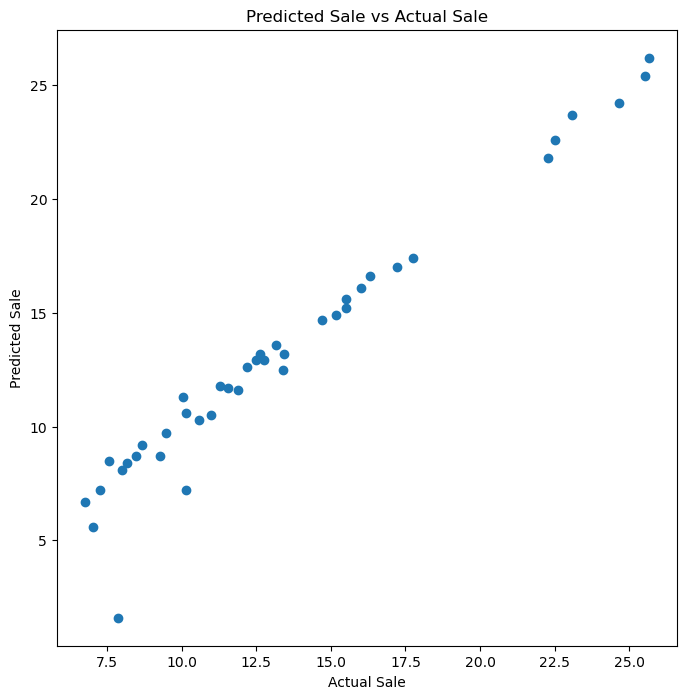

In [27]:
plt.figure(figsize=(8,8))

plt.scatter(y_pred, y_test.values)

plt.xlabel('Actual Sale')
plt.ylabel('Predicted Sale')

plt.title('Predicted Sale vs Actual Sale')
plt.show()

In [28]:
from sklearn.metrics import r2_score

In [29]:
r2_score(y_test, y_pred)

0.9545460317120982